In [1]:
import mlflow
from mlflow.tracking import MlflowClient
import matplotlib.pyplot as plt

from product_tagger.config import MLFLOW_TRACKING_URI

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()


2025-12-05 20:40:00.034 | INFO     | product_tagger.config:<module>:12 - PROJ_ROOT path is: C:\importante\Master\VC3\TP-VPC3
c:\importante\Master\VC3\TP-VPC3\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025-12-05 20:40:00.100 | INFO     | product_tagger.config:<module>:64 - [MLflow] tracking_uri = file:///C:/importante/Master/VC3/TP-VPC3/mlruns
2025-12-05 20:40:00.109 | INFO     | product_tagger.config:<module>:67 - [MLflow] experiment 'vit_aug_loss' -> id=899493669112892091, artifact_location=file:///C:/importante/Master/VC3/TP-VPC3/mlruns/899493669112892091


In [2]:
import pandas as pd

def get_metric_history_df(run_id: str, metric_key: str) -> pd.DataFrame:
    """
    Devuelve un DataFrame con columnas: step, value
    para la métrica dada en un run. Si no hay datos, devuelve df vacío.
    """
    hist = client.get_metric_history(run_id, metric_key)
    if not hist:
        return pd.DataFrame(columns=["step", "value"])

    data = [{"step": m.step, "value": m.value} for m in hist]
    return pd.DataFrame(data).sort_values("step")


In [3]:
from mlflow.tracking import MlflowClient
import mlflow
import pandas as pd

from product_tagger.config import MLFLOW_TRACKING_URI

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()

# 1) Obtener todos los experiments
experiments = client.search_experiments()
experiment_ids = [exp.experiment_id for exp in experiments]

print("Experiments encontrados:", len(experiments))
print("IDs:", experiment_ids)

# 2) Traer todos los runs de todos esos experiments
runs_all_df = mlflow.search_runs(
    experiment_ids=experiment_ids,
    max_results=10000,
)

print("Total runs encontrados:", len(runs_all_df))
runs_all_df.head()


Experiments encontrados: 3
IDs: ['747011836454282246', '899493669112892091', '274567506741654075']
Total runs encontrados: 3


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.val_f1_weighted,metrics.val_acc,metrics.val_loss,metrics.train_loss,...,params.model,params.weight_decay,params.augmentation,params.early_stopping_patience,params.label_col,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.git.commit
0,b4fd048ee13f4f0a8bd0912fc0c166fa,747011836454282246,FINISHED,file:///C:/importante/Master/VC3/TP-VPC3/mlrun...,2025-12-05 17:23:29.633000+00:00,2025-12-05 18:34:06.026000+00:00,0.818707,0.825904,0.625559,0.200961,...,vit_b_16,0.0001,none,5,articleType,C:\Users\pedro\TP-VPC3\product_tagger\modeling...,vit_articleType_no_aug,pedro,LOCAL,017546ab06509cc585e7f88fe1dd06d1687c86ce
1,3e49401539884875b18790273bf6b91e,899493669112892091,FINISHED,file:///C:/importante/Master/VC3/TP-VPC3/mlrun...,2025-12-04 23:31:39.503000+00:00,2025-12-05 02:11:26.825000+00:00,0.843698,0.853970,0.478731,0.331950,...,vit_b_16,0.0001,torchvision_flip_colorjitter_rotate,5,articleType,C:\importante\Master\VC3\TP-VPC3\product_tagge...,vit_articleType_aug,laum_,LOCAL,21371d82f15efb74006cbf8c1f597888b0836ed9
2,ad484a8bc4194f869d930c7f1706a398,274567506741654075,FINISHED,file:///C:/importante/Master/VC3/TP-VPC3/mlrun...,2025-12-03 19:08:40.259000+00:00,2025-12-03 21:47:21.890000+00:00,NaN,0.858022,0.478730,0.332265,...,vit_b_16,0.0001,torchvision_flip_colorjitter_rotate,None,articleType,C:\importante\Master\VC3\TP-VPC3\product_tagge...,vit_articleType_aug,laum_,LOCAL,3f04bb622f84dbf65f29b731c9599042478f28fb


In [4]:
cols = [
    "run_id",
    "experiment_id",
    "experiment_name",       
    "tags.mlflow.runName",
    "metrics.val_loss",
]

exp_id_to_name = {exp.experiment_id: exp.name for exp in experiments}
runs_all_df["experiment_name"] = runs_all_df["experiment_id"].map(exp_id_to_name)

runs_all_df[cols].head(20)


,run_id,experiment_id,experiment_name,tags.mlflow.runName,metrics.val_loss
0,b4fd048ee13f4f0a8bd0912fc0c166fa,747011836454282246,vit_articleType_no_aug,vit_articleType_no_aug,0.625559
1,3e49401539884875b18790273bf6b91e,899493669112892091,vit_aug_loss,vit_articleType_aug,0.478731
2,ad484a8bc4194f869d930c7f1706a398,274567506741654075,vit_aug_v1,vit_articleType_aug,0.478730


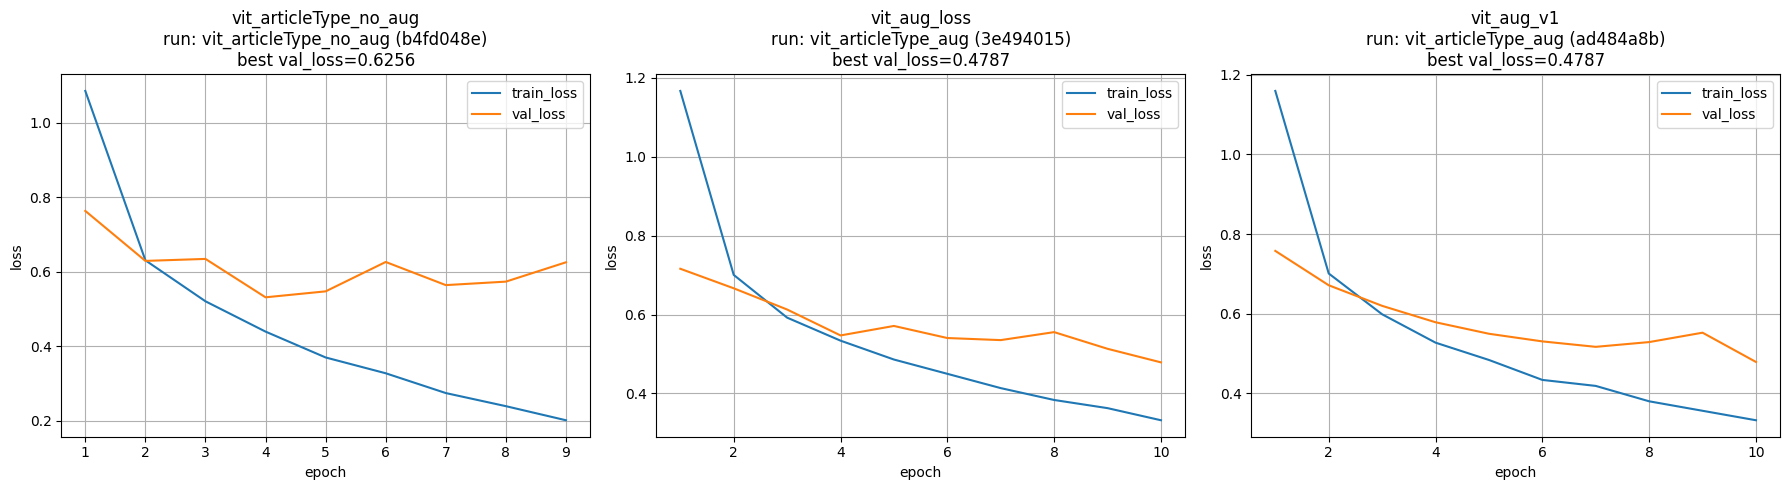

In [5]:
num_exps = len(experiments)
if num_exps == 0:
    raise ValueError("No hay experiments válidos en EXPERIMENT_NAMES.")

plt.figure(figsize=(6 * num_exps, 5))

for i, exp in enumerate(experiments, start=1):
    runs_df = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        max_results=1000,
    )

    plt.subplot(1, num_exps, i)

    if runs_df.empty:
        plt.title(f"{exp.name}\n(sin runs)")
        plt.text(0.5, 0.5, "No runs", ha="center", va="center")
        plt.axis("off")
        continue


    if "metrics.val_loss" in runs_df.columns:
        df_nonnull = runs_df.dropna(subset=["metrics.val_loss"])
        if df_nonnull.empty:
            best_row = runs_df.iloc[0]
        else:
            best_row = df_nonnull.sort_values("metrics.val_loss").iloc[0]
    else:
        best_row = runs_df.iloc[0]

    run_id = best_row["run_id"]
    run_name = best_row.get("tags.mlflow.runName", run_id[:8])
    best_val_loss = best_row.get("metrics.val_loss", None)

    df_train = get_metric_history_df(run_id, "train_loss")
    df_val   = get_metric_history_df(run_id, "val_loss")

    plotted_something = False

    if not df_train.empty:
        plt.plot(df_train["step"], df_train["value"], label="train_loss")
        plotted_something = True

    if not df_val.empty:
        plt.plot(df_val["step"], df_val["value"], label="val_loss")
        plotted_something = True

    if not plotted_something:
        plt.text(0.5, 0.5, "Sin historial de loss", ha="center", va="center")
        plt.axis("off")
    else:
        plt.xlabel("epoch")
        plt.ylabel("loss")
        title = f"{exp.name}\nrun: {run_name} ({run_id[:8]})"
        if best_val_loss is not None:
            title += f"\nbest val_loss={best_val_loss:.4f}"
        plt.title(title)
        plt.grid(True)
        plt.legend()

plt.tight_layout()
plt.show()



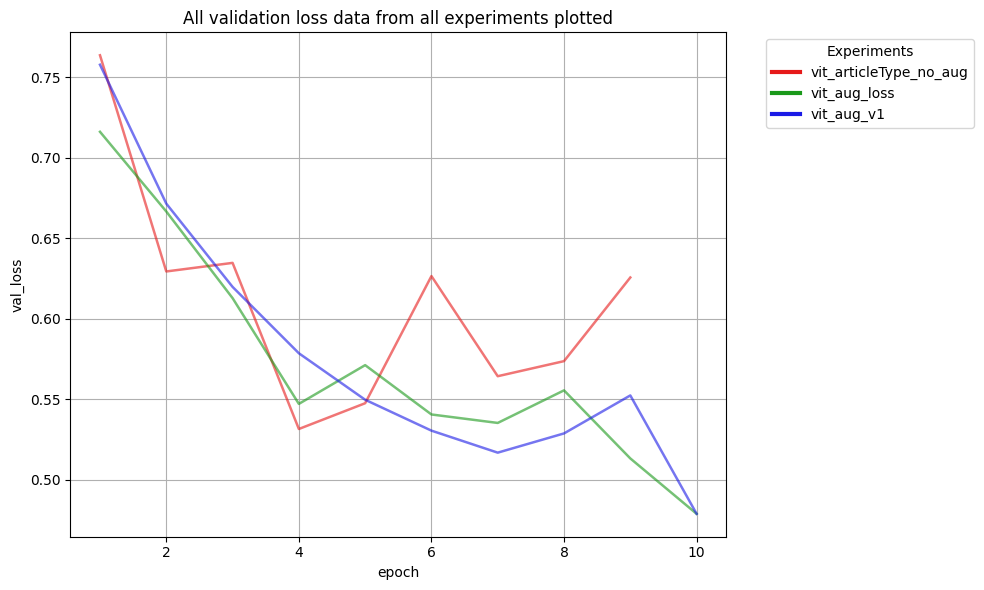

In [6]:
import itertools
import matplotlib.pyplot as plt

bold_colors = [
    (0.90, 0.10, 0.10),  # rojo fuerte
    (0.10, 0.60, 0.10),  # verde oscuro
    (0.10, 0.10, 0.90),  # azul fuerte
    (0.80, 0.50, 0.00),  # naranja oscuro
    (0.60, 0.00, 0.60),  # violeta fuerte
    (0.00, 0.70, 0.70),  # cian oscuro
    (0.40, 0.00, 0.00),  # rojo sangre
    (0.00, 0.30, 0.60),  # azul petróleo
    (0.40, 0.30, 0.00),  # marrón oscuro
    (0.00, 0.60, 0.20),  # verde esmeralda
]

color_cycle = itertools.cycle(bold_colors)
color_by_exp = {exp.experiment_id: next(color_cycle) for exp in experiments}

plt.figure(figsize=(10, 6))
num_plotted = 0

for exp in experiments:
    exp_id = exp.experiment_id

    runs_df = mlflow.search_runs(
        experiment_ids=[exp_id],
        max_results=1000,
        order_by=["start_time ASC"],
    )

    if runs_df.empty:
        continue

    for _, row in runs_df.iterrows():
        run_id = row["run_id"]
        df_loss = get_metric_history_df(run_id, "val_loss")
        if df_loss.empty:
            continue

        plt.plot(
            df_loss["step"],
            df_loss["value"],
            color=color_by_exp[exp_id],
            alpha=0.6,
            linewidth=1.8,
        )
        num_plotted += 1

plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("All validation loss data from all experiments plotted")
plt.grid(True)

handles = []
labels = []
for exp in experiments:
    handles.append(plt.Line2D([0], [0], color=color_by_exp[exp.experiment_id], lw=3))
    labels.append(exp_id_to_name[exp.experiment_id])

plt.legend(handles, labels, title="Experiments", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

